## Setup

In [5]:
from microbiome_gpt.utils.fig_style import apply_style

apply_style(font_family="DejaVu Serif", base_font_size=16)

In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from microbiome_gpt.utils.project_paths import find_data_path, find_figures_path

data_path = find_data_path()
figures_path = find_figures_path()

## Read Data

In [8]:
metadata = pd.read_csv(f"{data_path}/from_zuza/metadata.csv", index_col= [0], low_memory=False).sort_index()
taxonomy = pd.read_csv(f"{data_path}/from_zuza/train_taxonomy21k.csv", index_col = [0]).sort_index() * 100
pathways = pd.read_csv(f"{data_path}/from_zuza/train_pathways21k.csv", index_col = [0]).sort_index() * 100

metadata = metadata.query("sample_id in @taxonomy.index")

# Figure 1A - Disease Overview

In [20]:
diseases_df = (metadata['study_condition']
    .value_counts()
    .reset_index()
    .rename(columns={'study_condition': 'disease', 'count': 'count'})
    .query("disease != 'control'"))

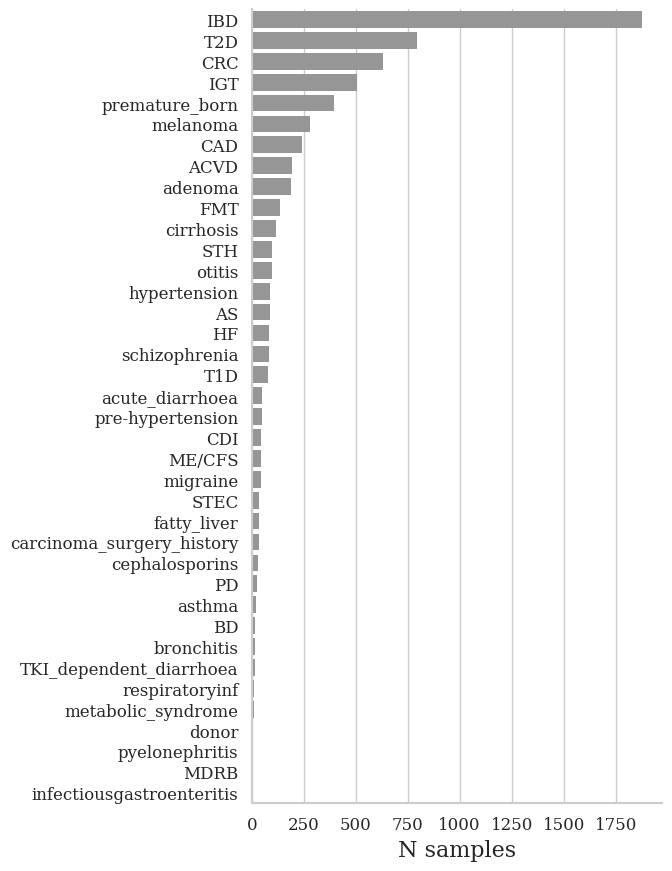

In [21]:
fig, ax = plt.subplots(figsize=(7, 9))

sns.barplot(
    data=diseases_df,
    x="count", y="disease",
    color="#969696",
    edgecolor="none",
    ax=ax
)
ax.set(xlabel="N samples", ylabel="")
sns.despine(left=False, right=True, top=True, bottom=False)

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1A.png", dpi=300)

# Figure 1B - Count by Countries

In [22]:
count_by_country_df = metadata['country'].value_counts().reset_index()

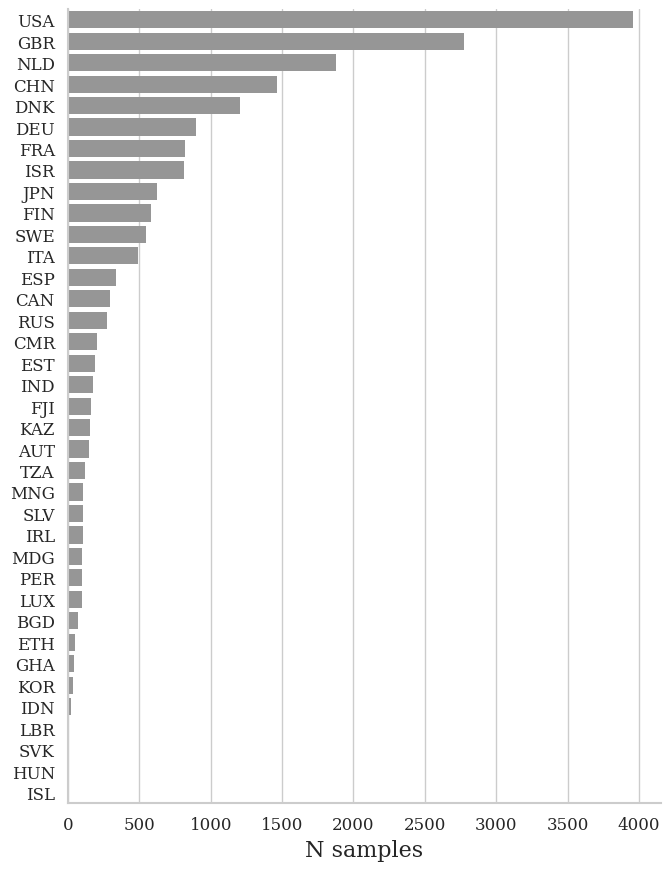

In [23]:
fig, ax = plt.subplots(figsize=(7, 9))

sns.barplot(
    data=diseases_df,
    x='count', y='country',
    color='#969696',
    ax=ax,
    edgecolor='none'
)
ax.set(xlabel="N samples", ylabel="")
sns.despine(left=False, right=True, top=True, bottom=False)

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1B.png", dpi=300)

# Figure 1C - Age Distribution

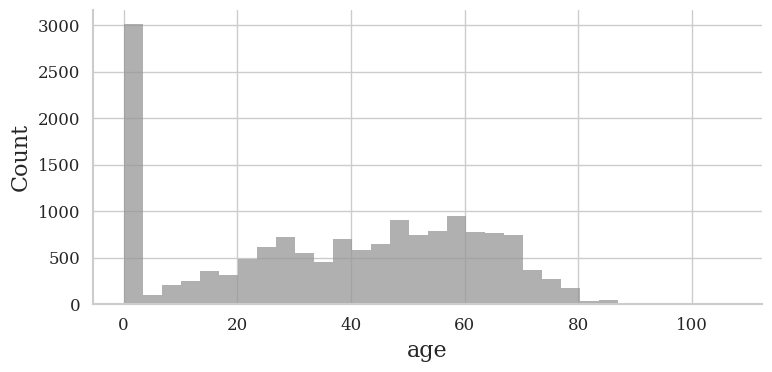

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    metadata.age,
    color='#969696',
    edgecolor='none'
)
sns.despine(left=False, right=True, top=True, bottom=False)
ax.set(xlabel="age")

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1C.png", dpi=300)

# Figure 1D - Gender Distribution

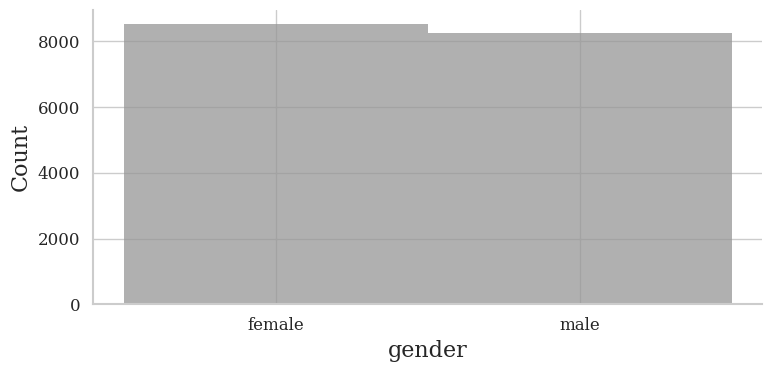

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    metadata.gender,
    color='#969696',
    edgecolor='none'
)
sns.despine(left=False, right=True, top=True, bottom=False)
ax.set_xlabel('gender')

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1D.png", dpi=300)